# Evaluating spectral separability

This notebook can be used to evaluate spectral separability of point-spectra using three methods: Hierarchical Cluster Analysis, Spectral Angle Classification, and Random Forest Classification.

### Set-up 
importing modules and data

In [24]:
# Import required scripts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import speca.label_data as sld
import speca.plot_data as spd
import speca.resampling as srs

In [25]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [181]:
# Import data from .csv
path = r".\data\MEL_NZ_TAS_spectra.csv"
data = pd.read_csv(path)

## Pre-process data

In [182]:
# Create and preview labels for various grouping schemes

labels = sld.label_the_data(data)
#labels.to_csv(r".\data\MEL_NZ_TAS_labels.csv", index=False)

## Prepare data for plotting

In [177]:
# Define data formatting and filtering parameters:
scheme = "all" # "kelp", "browns", "farm"
target_sites = ["new_zealand", "melbourne", "tasmania"]
target_setup = ["handheld"]
bad_bands_list = map(str,list(range(753, 769)))

In [178]:
# Format the data
formatted_data = spd.format_for_plotting(data, labels, bad_bands_list)

# Filter to targets of interest
filtered_labels, filtered_data = spd.filter_for_plotting(formatted_data, labels, scheme = "all", target_setup = ["handheld"], target_sites= target_sites)

# Crop out noisy wavelengths
cropped_data = spd.crop_noisy_wavelengths(filtered_data, "400", "900")

# Scale the data
scaled_data = spd.scale_data(cropped_data, "standard")

# Calculate the class specific stats
class_stats_dict = spd.class_stats(scaled_data, filtered_labels, grouping = "Class", plot_by_site= False)

# # OR run prepping chain
# results = spd.prepping_chain(data, labels)

In [168]:
# Choose what to plot
search_words = ['acrocarpia',
                'cystophora',
                'carpophyllum',
                'durvillaea',
                'hormosira',
                'phyllospora',
                'sargassum',
                'scytosiphon']
search_sites = []

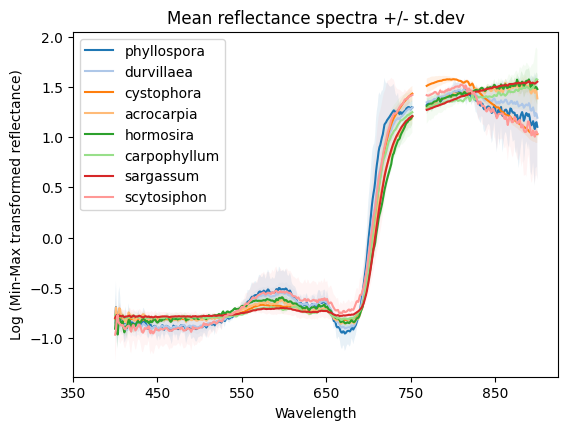

In [179]:
#Call the plotting function according to the desired search words, mode, bad bands
spd.plot_search_terms(search_words, search_sites, any, class_stats_dict, start_wavelength= 400)

## Resample to satellite RSRs